In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aryashah2k/breast-ultrasound-images-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/breast-ultrasound-images-dataset


In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras import layers, Model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy, BinaryCrossentropy
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split

Top-level folders (categories or patient groups):
['benign', 'normal', 'malignant']

Example files in 'benign' folder:
['benign (2).png', 'benign (285).png', 'benign (166)_mask.png', 'benign (290)_mask.png', 'benign (300).png']

Image counts per category:
benign: 891 files
normal: 266 files
malignant: 421 files

Sample 1
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.98]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


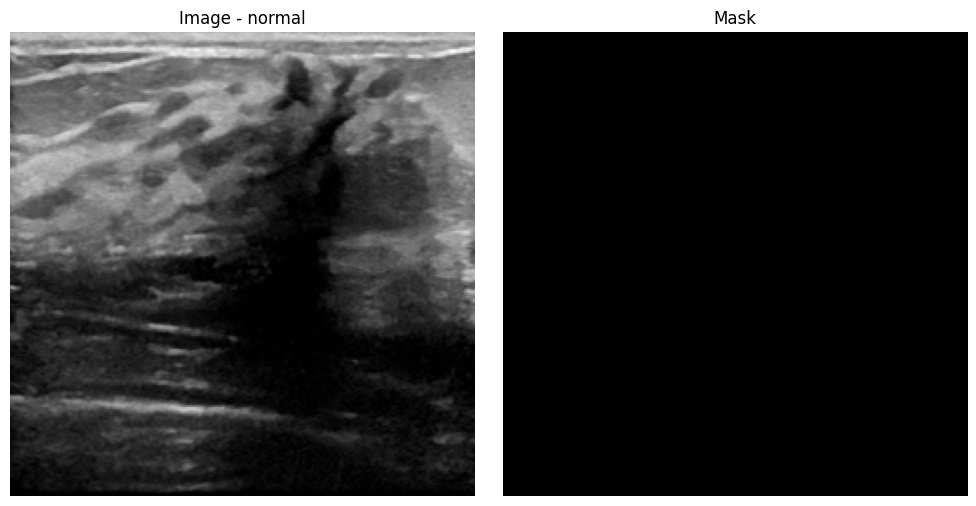


Sample 2
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.99]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


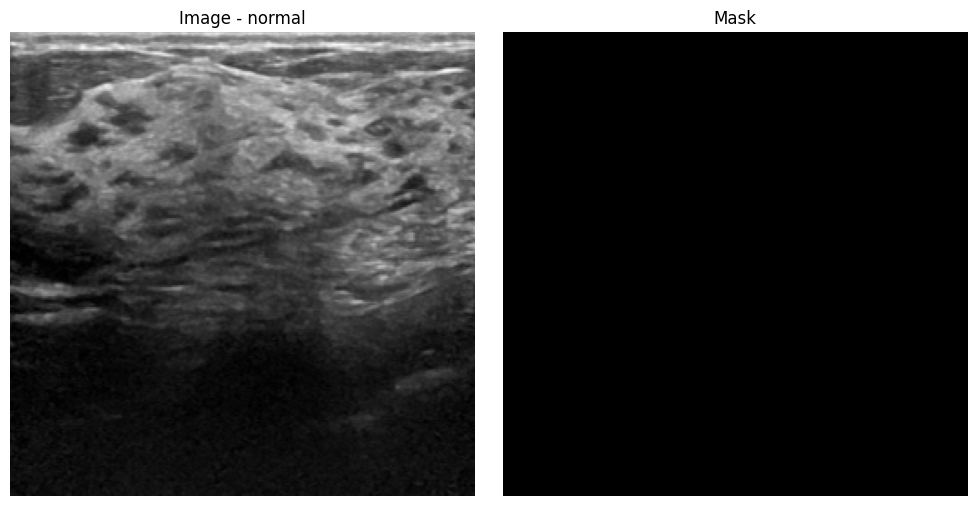


Sample 3
Label: normal
Image shape: (256, 256, 3), pixel range: [0.01, 1.00]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


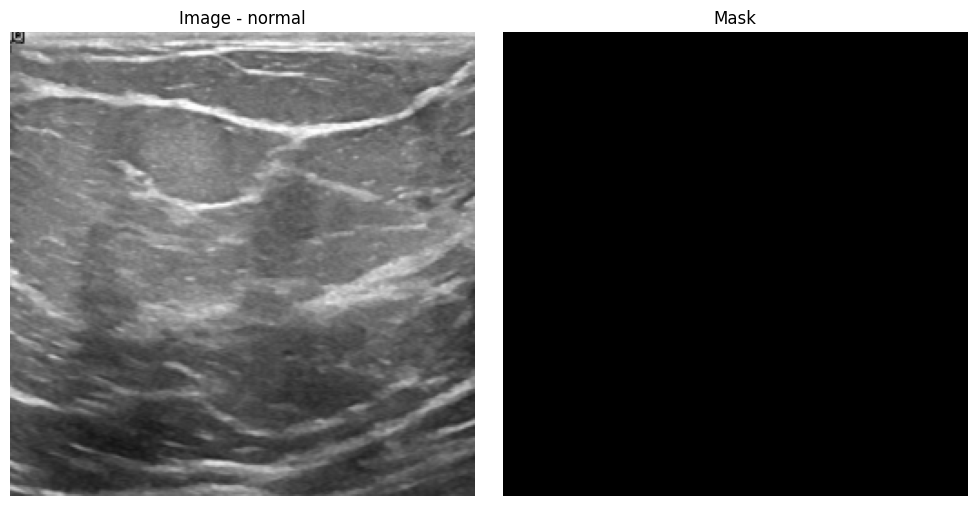


Sample 4
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.99]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


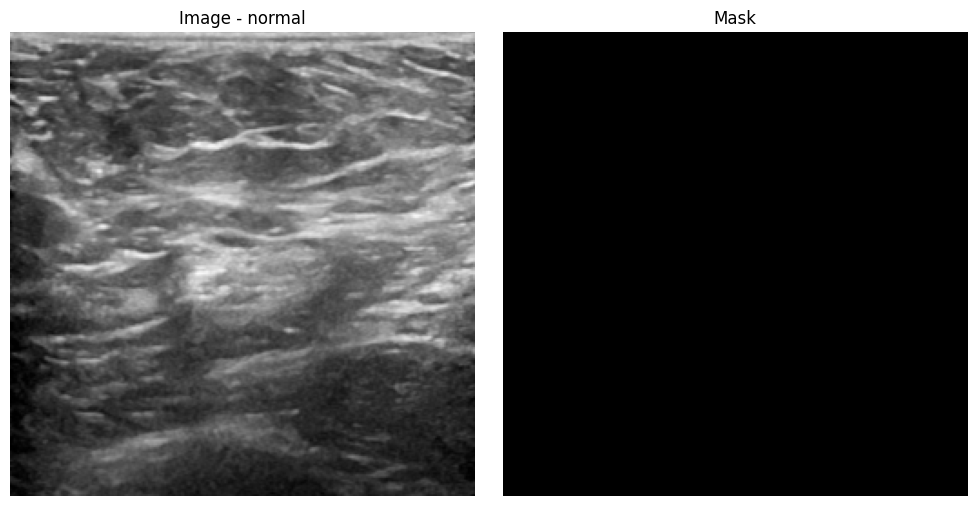


Sample 5
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.92]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


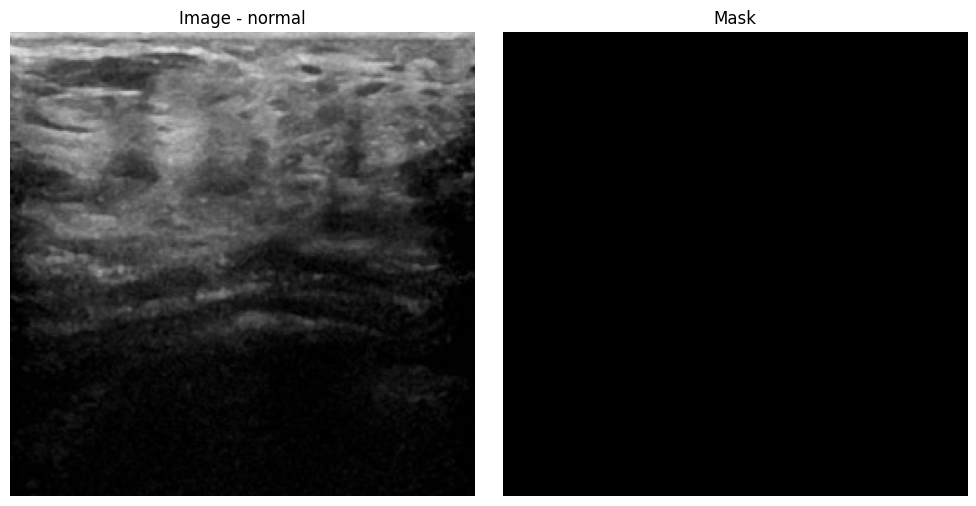

Training images: 624
Testing images: 156
Training masks: 624
Testing masks: 156
Training labels: 624
Testing labels: 156


In [29]:


# Define the dataset path
dataset_path = '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/'

# List the subdirectories (usually categories or patients)
subdirs = os.listdir(dataset_path)
print("Top-level folders (categories or patient groups):")
print(subdirs)

# Dive into one folder (e.g., 'benign')
sample_folder = os.path.join(dataset_path, 'benign')
print("\nExample files in 'benign' folder:")
print(os.listdir(sample_folder)[:5])  # Show first 5 files

# Print the total number of images in each folder
print("\nImage counts per category:")
for category in subdirs:
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):
        num_images = len(os.listdir(category_path))
        print(f"{category}: {num_images} files")

def load_image(path, size, is_mask=False):
    """Load and resize a single image or mask."""
    img = load_img(path, color_mode='grayscale' if is_mask else 'rgb')
    img = img_to_array(img) / 255.0  # Normalize to [0, 1]
    img = resize(img, (size, size), preserve_range=True, anti_aliasing=True)

    if is_mask:
        if img.ndim == 2:  # In case shape is (256, 256)
            img = np.expand_dims(img, axis=-1)
        elif img.shape[-1] != 1:  # In case it's (256, 256, n)
            img = img[..., :1]
    return img

def load_images(paths, size=256, is_mask=False, limit=None):
    """Load and resize multiple images."""
    if limit:
        paths = paths[:limit]
    
    channels = 1 if is_mask else 3
    images = np.zeros((len(paths), size, size, channels), dtype=np.float32)
    
    for i, path in enumerate(paths):
        images[i] = load_image(path, size, is_mask)
    
    return images


def show_samples(images, masks, image_paths, count=5):
    """Display image-mask pairs with labels extracted from file paths."""
    for i in range(count):
        image = images[i]
        mask = masks[i]
        
        # Extract label from the path (e.g., .../benign/xxx.png → "benign")
        label = os.path.basename(os.path.dirname(image_paths[i]))

        print(f"\nSample {i + 1}")
        print(f"Label: {label}")
        print(f"Image shape: {image.shape}, pixel range: [{image.min():.2f}, {image.max():.2f}]")
        print(f"Mask shape: {mask.shape}, pixel range: [{mask.min():.2f}, {mask.max():.2f}]")

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(image)
        ax[0].set_title(f"Image - {label}")
        ax[0].axis("off")

        ax[1].imshow(mask.squeeze(), cmap="gray")
        ax[1].set_title("Mask")
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()


# Set image size for resizing
SIZE = 256

def load_data(dataset_path, size=256, limit=None):
    """Load and preprocess the data."""
    image_paths = []
    mask_paths = []
    labels = []
    
    # List subdirectories for categories (normal, benign, malignant)
    categories = ['normal', 'benign', 'malignant']

    for label in categories:
        label_dir = os.path.join(dataset_path, label)
        
        for file in os.listdir(label_dir):
            if file.endswith('.png'):
                if '_mask' in file:
                    mask_paths.append(os.path.join(label_dir, file))
                else:
                    image_paths.append(os.path.join(label_dir, file))
                    labels.append(label)
    
    # Ensure each image has a corresponding mask
    valid_image_paths = []
    valid_mask_paths = []
    valid_labels = []

    for img_path in image_paths:
        mask_path = img_path.replace('.png', '_mask.png')
        if mask_path in mask_paths:
            valid_image_paths.append(img_path)
            valid_mask_paths.append(mask_path)
            valid_labels.append(labels[image_paths.index(img_path)])

    # Synchronize images, masks, and labels
    images = load_images(valid_image_paths, size=size, is_mask=False, limit=limit)
    masks = load_images(valid_mask_paths, size=size, is_mask=True, limit=limit)

    # Convert labels to numerical values
    label_map = {"normal": 0, "benign": 1, "malignant": 2}
    numerical_labels = np.array([label_map[label] for label in valid_labels])

    # Show some sample image-mask pairs
    show_samples(images, masks, valid_image_paths, count=5)

    return images, masks, numerical_labels, valid_image_paths, valid_mask_paths


# Load and preprocess data
images, masks, labels, image_paths, mask_paths = load_data(dataset_path, size=SIZE)

# Split data into training and testing (80/20 split)
X_train, X_test, y_train, y_test, mask_train, mask_test = train_test_split(
    images, labels, masks, test_size=0.2, random_state=42
)

print(f"Training images: {len(X_train)}")
print(f"Testing images: {len(X_test)}")
print(f"Training masks: {len(mask_train)}")
print(f"Testing masks: {len(mask_test)}")
print(f"Training labels: {len(y_train)}")
print(f"Testing labels: {len(y_test)}")


In [30]:
def extract_paths_and_labels(dataset_path):
    image_paths = []
    mask_paths = []
    labels = []

    label_map = {'benign': 0, 'malignant': 1, 'normal': 2}

    for label_name, label_value in label_map.items():
        image_dir = os.path.join(dataset_path, label_name)
        if not os.path.isdir(image_dir):
            continue

        for fname in os.listdir(image_dir):
            if fname.endswith('.png') and 'mask' not in fname.lower():
                img_path = os.path.join(image_dir, fname)
                mask_name = fname.replace('.png', '_mask.png')
                mask_path = os.path.join(image_dir, mask_name)

                if os.path.exists(mask_path):  # Only include samples that have masks
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)
                    labels.append(label_value)

    return image_paths, mask_paths, labels

In [31]:
import matplotlib.pyplot as plt

def show_malignant_samples(images, masks, labels, image_paths, count=3):
    """Display 'count' malignant image-mask pairs."""
    malignant_indices = [i for i, label in enumerate(labels) if label == 2]  # 2 = malignant
    selected_indices = malignant_indices[:count]

    plt.figure(figsize=(12, 4 * count))

    for idx, i in enumerate(selected_indices):
        # Show image
        plt.subplot(count, 2, 2*idx + 1)
        plt.imshow(images[i])
        plt.title(f"Malignant Image\n{os.path.basename(image_paths[i])}")
        plt.axis('off')

        # Show corresponding mask
        plt.subplot(count, 2, 2*idx + 2)
        plt.imshow(masks[i].squeeze(), cmap='gray')
        plt.title("Corresponding Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()



Sample 1
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.98]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


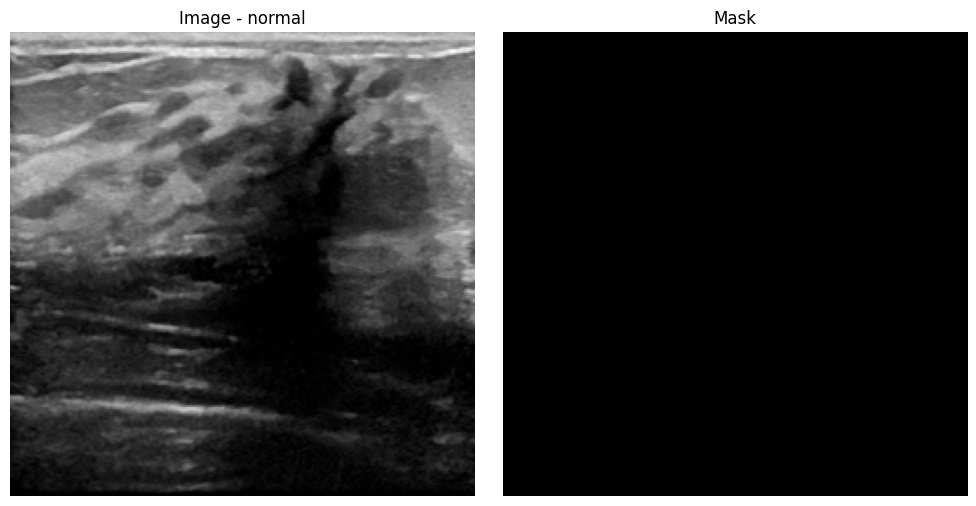


Sample 2
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.99]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


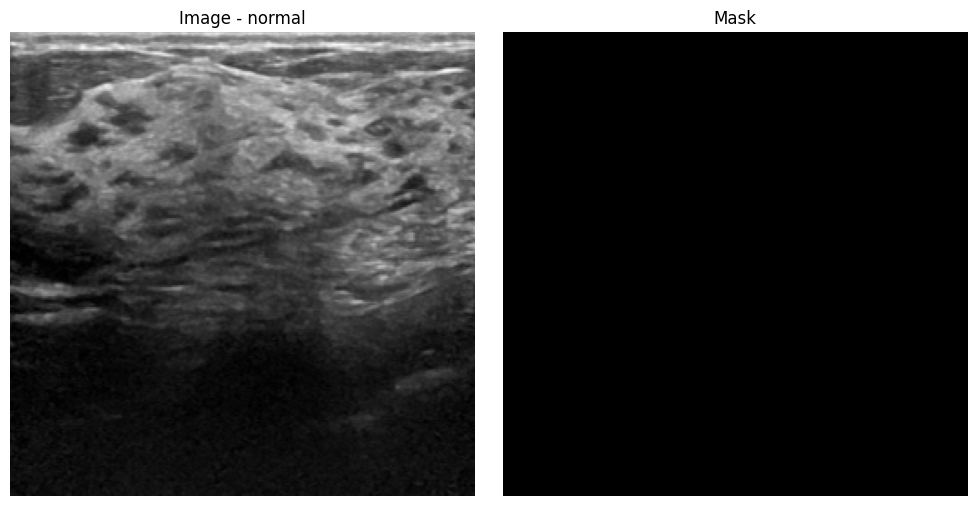


Sample 3
Label: normal
Image shape: (256, 256, 3), pixel range: [0.01, 1.00]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


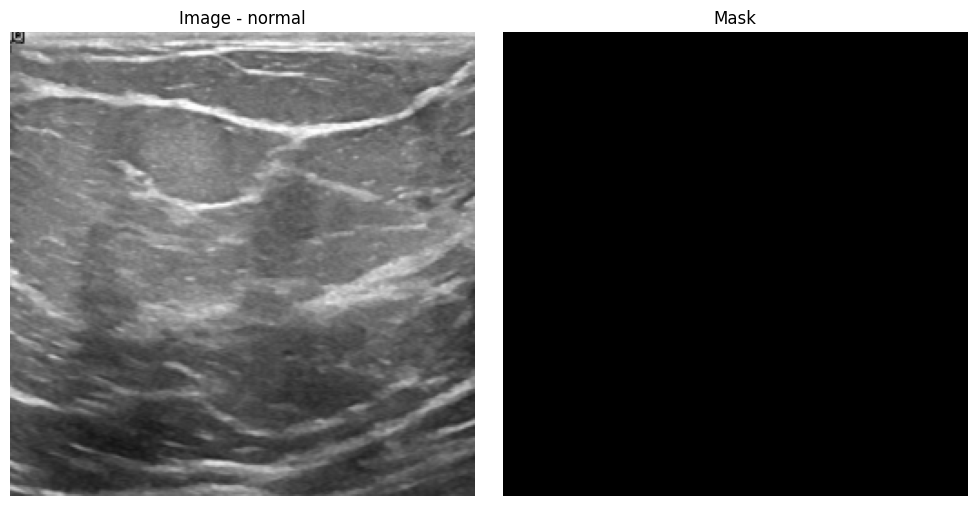


Sample 4
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.99]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


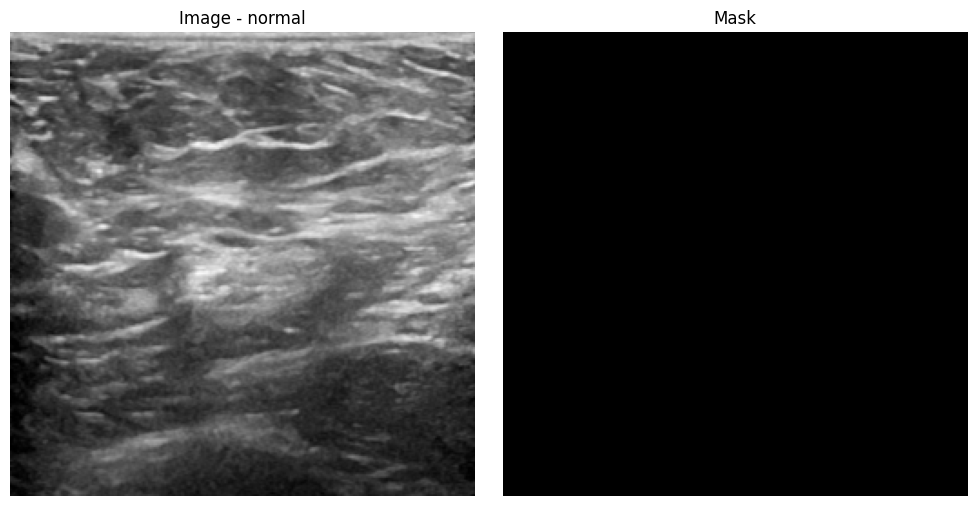


Sample 5
Label: normal
Image shape: (256, 256, 3), pixel range: [0.00, 0.92]
Mask shape: (256, 256, 1), pixel range: [0.00, 0.00]


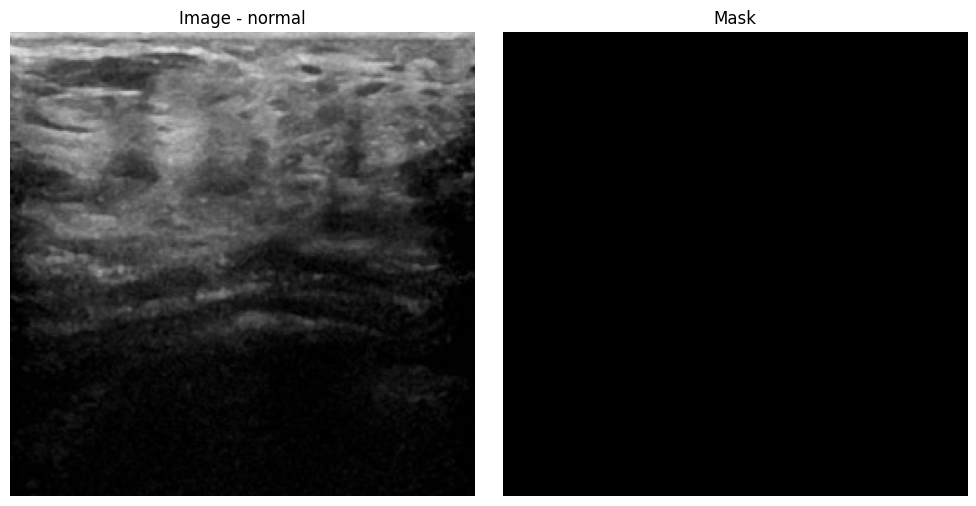

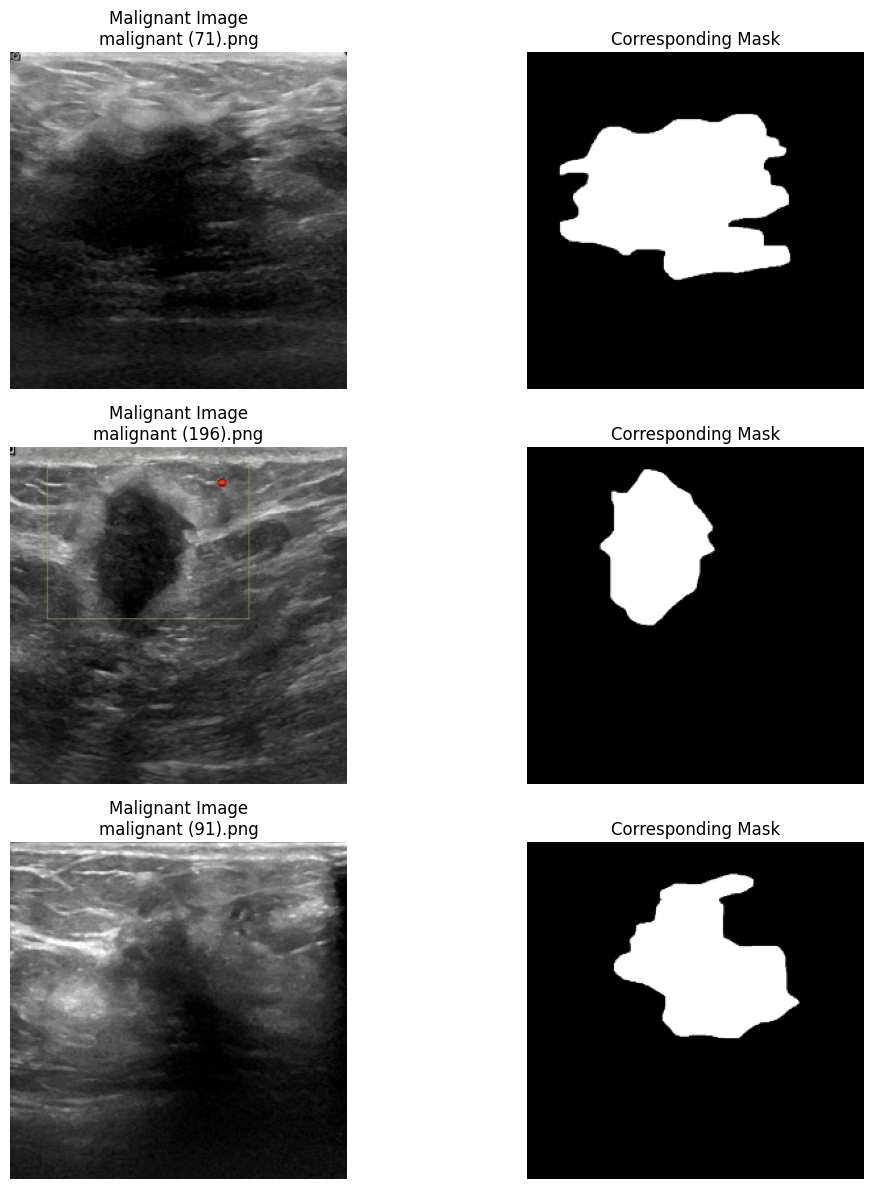

In [32]:
images, masks, labels, image_paths, _ = load_data(dataset_path, size=256)
show_malignant_samples(images, masks, labels, image_paths, count=3)


In [42]:
from tensorflow.keras import layers, Model

def multi_task_unet(input_size=(256,256,3)):
    inputs = layers.Input(input_size)

    # Encoder (3 pools)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)            # 256→128

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)            # 128→64

    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D(2)(c3)            # 64→32

    # Bottleneck (no pool)
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    bn = layers.Conv2D(512, 3, activation='relu', padding='same')(bn)

    # Decoder (3 upsamples)
    u3 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(bn)  # 32→64
    u3 = layers.concatenate([u3, c3], axis=-1)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u3)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)

    u2 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c4)  # 64→128
    u2 = layers.concatenate([u2, c2], axis=-1)
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(c5)

    u1 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c5)   # 128→256
    u1 = layers.concatenate([u1, c1], axis=-1)
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(c6)

    # Segmentation output (256×256)
    seg_out = layers.Conv2D(1, 1, activation='sigmoid', name='segmentation')(c6)

    # Classification head (on bottleneck)
    cls = layers.GlobalAveragePooling2D()(bn)
    cls = layers.Dense(64, activation='relu')(cls)
    cls_out = layers.Dense(3, activation='softmax', name='classification')(cls)

    return Model(inputs, [seg_out, cls_out])


In [43]:


def dice_loss(y_true, y_pred, smooth=1):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2. * intersection + smooth) / (union + smooth)

def combined_loss(seg_true, seg_pred, cls_true, cls_pred, alpha=0.5, beta=0.5):
    seg_loss = dice_loss(seg_true, seg_pred)
    cls_loss = CategoricalCrossentropy()(cls_true, cls_pred)
    return alpha * seg_loss + beta * cls_loss


# Optimizer
optimizer = Adam(learning_rate=1e-4)

In [44]:
def run_training(dataset_path):
    # 1. Collect paths & labels
    image_paths, mask_paths, labels = extract_paths_and_labels(dataset_path)
    labels = to_categorical(labels, num_classes=3)

    # 2. Load & preprocess
    SIZE = 256
    images = load_images(image_paths, size=SIZE, is_mask=False)
    masks  = load_images(mask_paths,  size=SIZE, is_mask=True)

    # 3. Split 80/20
    X_train, X_test, y_mask_train, y_mask_test, y_cls_train, y_cls_test = train_test_split(
        images, masks, labels,
        test_size=0.2,
        random_state=42,
        stratify=labels.argmax(axis=1)
    )

    # 4. Build & compile model
    model = multi_task_unet(input_size=(SIZE, SIZE, 3))
    model.compile(
        optimizer=Adam(1e-4),
        loss={
          'segmentation': dice_loss,
          'classification': CategoricalCrossentropy()
        },
        loss_weights={'segmentation': 0.6, 'classification': 0.4},
        metrics={'classification': 'accuracy'}
    )

    # 5. Callbacks
    callbacks = [
      EarlyStopping(patience=10, restore_best_weights=True),
      ReduceLROnPlateau(patience=5, factor=0.5)
    ]

    # 6. Train
    model.fit(
      X_train,
      {'segmentation': y_mask_train, 'classification': y_cls_train},
      validation_data=(X_test, {'segmentation': y_mask_test, 'classification': y_cls_test}),
      epochs=50,
      batch_size=8,
      callbacks=callbacks
    )

    # Return model and test data
    return model, X_test, y_mask_test, y_cls_test



In [45]:
# Define the path to your dataset
dataset_path = '/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/'

# Run the training process and get the model + test data
model, X_test, y_mask_test, y_cls_test = run_training(dataset_path)

# Save the trained model
model.save('multi_task_unet_model.h5')

# Evaluate
evaluate_model(model, X_test, y_mask_test, y_cls_test)


Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 49s 466ms/step - classification_accuracy: 0.5529 - classification_loss: 1.0085 - loss: 0.9248 - segmentation_loss: 0.8690 - val_classification_accuracy: 0.5577 - val_classification_loss: 0.9533 - val_loss: 0.8838 - val_segmentation_loss: 0.8340 - learning_rate: 1.0000e-04
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 31s 401ms/step - classification_accuracy: 0.5515 - classification_loss: 0.9832 - loss: 0.8745 - segmentation_loss: 0.8020 - val_classification_accuracy: 0.5577 - val_classification_loss: 0.9412 - val_loss: 0.7846 - val_segmentation_loss: 0.6703 - learning_rate: 1.0000e-04
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 407ms/step - classification_accuracy: 0.5398 - classification_loss: 0.9624 - loss: 0.8043 - segmentation_loss: 0.6989 - val_classification_accuracy: 0.5577 - val_classification_loss: 0.9325 - val_loss: 0.7815 - val_segmentation_loss: 0.6715 - learning_rate: 1.0000e-04
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 405ms/step - classificati

E0000 00:00:1747119653.081254     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747119653.342828     103 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5/5 ━━━━━━━━━━━━━━━━━━━━ 55s 7s/step 

--- Segmentation Metrics ---
Dice Coefficient: 0.6033
Mean IoU: 0.4320
Pixel Accuracy: 0.9394

--- Classification Metrics ---
Accuracy: 0.7756
Precision: 0.7469
Recall: 0.7826
F1-Score: 0.7609

Classification Report:
              precision    recall  f1-score   support

      benign       0.85      0.78      0.81        87
   malignant       0.71      0.71      0.71        42
      normal       0.68      0.85      0.75        27

    accuracy                           0.78       156
   macro avg       0.75      0.78      0.76       156
weighted avg       0.78      0.78      0.78       156



In [49]:


def evaluate_model(model, X_test, y_mask_test, y_cls_test):
    # Predict on test data
    preds = model.predict(X_test)
    pred_masks = preds[0]
    pred_classes = preds[1]

    # --- Segmentation Metrics ---
    def dice_coef(y_true, y_pred, smooth=1):
        y_true_f = y_true.flatten()
        y_pred_f = y_pred.flatten()
        intersection = np.sum(y_true_f * y_pred_f)
        return (2. * intersection + smooth) / (np.sum(y_true_f) + np.sum(y_pred_f) + smooth)

    def pixel_accuracy(y_true, y_pred):
        y_true = y_true.astype(np.bool_)
        y_pred = y_pred.astype(np.bool_)
        return np.mean(y_true == y_pred)

    def mean_iou(y_true, y_pred, smooth=1e-6):
        y_true_f = y_true.flatten()
        y_pred_f = y_pred.flatten()
        intersection = np.sum(y_true_f * y_pred_f)
        union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
        return (intersection + smooth) / (union + smooth)

    # Binarize mask predictions
    pred_masks_bin = (pred_masks > 0.5).astype(np.float32)

    dice = dice_coef(y_mask_test, pred_masks_bin)
    iou = mean_iou(y_mask_test, pred_masks_bin)
    pixel_acc = pixel_accuracy(y_mask_test, pred_masks_bin)

    print("\n--- Segmentation Metrics ---")
    print(f"Dice Coefficient: {dice:.4f}")
    print(f"Mean IoU: {iou:.4f}")
    print(f"Pixel Accuracy: {pixel_acc:.4f}")

    # --- Classification Metrics ---
    y_true_cls = np.argmax(y_cls_test, axis=1)
    y_pred_cls = np.argmax(pred_classes, axis=1)

    accuracy = accuracy_score(y_true_cls, y_pred_cls)
    precision = precision_score(y_true_cls, y_pred_cls, average='macro')
    recall = recall_score(y_true_cls, y_pred_cls, average='macro')
    f1 = f1_score(y_true_cls, y_pred_cls, average='macro')

    print("\n--- Classification Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Optional: Full classification report
    print("\nClassification Report:")
    print(classification_report(y_true_cls, y_pred_cls, target_names=['benign', 'malignant', 'normal']))


In [50]:
evaluate_model(model, X_test, y_mask_test, y_cls_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 495ms/step

--- Segmentation Metrics ---
Dice Coefficient: 0.6033
Mean IoU: 0.4320
Pixel Accuracy: 0.9394

--- Classification Metrics ---
Accuracy: 0.7756
Precision: 0.7469
Recall: 0.7826
F1-Score: 0.7609

Classification Report:
              precision    recall  f1-score   support

      benign       0.85      0.78      0.81        87
   malignant       0.71      0.71      0.71        42
      normal       0.68      0.85      0.75        27

    accuracy                           0.78       156
   macro avg       0.75      0.78      0.76       156
weighted avg       0.78      0.78      0.78       156

